In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor
import lightgbm as lgb

In [4]:
df = pd.read_csv("../data/processed/sales_cleaned.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Competitor Pricing,Seasonality,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,85.73,Winter,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,92.02,Winter,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,60.08,Winter,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,85.19,Winter,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,51.63,Winter,59


In [6]:
X = df[["Price", "Inventory Level"]]
y = df["Units Sold"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [10]:
xgb_pred = xgb_model.predict(X_test)

In [11]:
print("XGBoost MAE:", mean_absolute_error(y_test, xgb_pred))
print("XGBoost R2:", r2_score(y_test, xgb_pred))

XGBoost MAE: 31.73389434814453
XGBoost R2: 0.12391573190689087


In [12]:
lgb_model = lgb.LGBMRegressor()

lgb_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 60800, number of used features: 2
[LightGBM] [Info] Start training from score 88.807352


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [13]:
lgb_pred = lgb_model.predict(X_test)

In [14]:
print("LightGBM MAE:", mean_absolute_error(y_test, lgb_pred))
print("LightGBM R2:", r2_score(y_test, lgb_pred))

LightGBM MAE: 31.492677995823318
LightGBM R2: 0.13982972587885445


In [15]:
df_test = X_test.copy()
df_test["Actual_Demand"] = y_test
df_test["Predicted_Demand"] = xgb_pred
df_test["Price"] = X_test["Price"]

df_test["Actual_Revenue"] = df_test["Price"] * df_test["Actual_Demand"]
df_test["Predicted_Revenue"] = df_test["Price"] * df_test["Predicted_Demand"]

print("Actual Revenue:", df_test["Actual_Revenue"].sum())
print("Predicted Revenue:", df_test["Predicted_Revenue"].sum())

Actual Revenue: 91477835.38000001
Predicted Revenue: 91579048.2398881


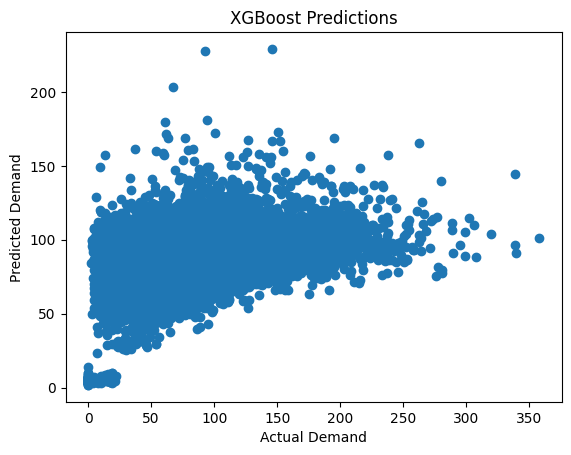

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test, xgb_pred)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("XGBoost Predictions")
plt.show()

In [ ]:

df_test = X_test.copy()

df_test["Actual_Demand"] = y_test

df_test["Predicted_Demand"] = xgb_pred

df_test["Original_Price"] = X_test["Price"]

df_test["Dynamic_Price"] = df_test["Original_Price"]

df_test.loc[df_test["Predicted_Demand"] > df_test["Actual_Demand"], "Dynamic_Price"] = df_test["Original_Price"] * 1.10
df_test.loc[df_test["Predicted_Demand"] < df_test["Actual_Demand"], "Dynamic_Price"] = df_test["Original_Price"] * 0.95


df_test["Static_Revenue"] = df_test["Original_Price"] * df_test["Actual_Demand"]

df_test["Dynamic_Revenue"] = df_test["Dynamic_Price"] * df_test["Predicted_Demand"]


static_rev = df_test["Static_Revenue"].sum()
dynamic_rev = df_test["Dynamic_Revenue"].sum()


revenue_lift = ((dynamic_rev - static_rev) / static_rev) * 100

print("Static Revenue:", static_rev)
print("Dynamic Revenue:", dynamic_rev)
print("Revenue Lift (%):", revenue_lift)

Static Revenue: 91477835.38000001
Dynamic Revenue: 94354754.75326857
Revenue Lift (%): 3.1449359960451653
